<a href="https://colab.research.google.com/github/omkar-2483/Machine-Learning-Deep-Learning/blob/main/D3-Deep-Learning-with-PyTorch/Deep_Learning_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tensor

Import Tensor and check for CUDA Availability

In [ ]:
import torch
torch.cuda.is_available()

True

# Creating Tensor and Operation

In [ ]:
first_tensor = torch.tensor([[1,2,3,4],[5,6,7,8]])
second_tensor = torch.tensor([[2,3,5,4],[6,4,6,3]])

# addition
print(first_tensor+second_tensor)

tensor([[ 3,  5,  8,  8],
        [11, 10, 13, 11]])


In [ ]:
# substraction
print(first_tensor-second_tensor)

tensor([[-1, -1, -2,  0],
        [-1,  2,  1,  5]])


To allocate Tensor to GPU

In [ ]:
if torch.cuda.is_available(): device = 'cuda'
else: device='cpu'

print(device)

cuda


In [ ]:
ten_a = torch.tensor([[1,2,3,4],[5,6,7,8]], device = device)
ten_b = torch.tensor([[2,3,5,4],[6,4,6,3]], device = device)
multi_ten = ten_a * ten_b
print(multi_ten)

tensor([[ 2,  6, 15, 16],
        [30, 24, 42, 24]], device='cuda:0')


Note that output is also allocated to GPU. cuda:0 inicate that tensor is allocated to first GPU

# Moving Tensor between CPUs and GPUs


Tensors are moved between CPUs and GPUs to leverage the GPU's faster processing capabilities, especially for large-scale neural network training.

* **CPU to GPU:** When training large neural networks or handling high-dimensional data (like images) that require faster computation, we move tensors to the GPU. This is because GPUs are optimized for parallel processing and can significantly speed up training.

* **GPU to CPU:** After training, if the output tensors need pre-processing and the libraries used (like NumPy) only support CPU data, we move the tensors back to the CPU. This ensures compatibility with these libraries for further data manipulation.

# Different Ways to Create Tensor

**Creating Tensors from Python Objects:**
You can create tensors from lists, tuples, or NumPy arrays using the torch.tensor method.



In [ ]:
# initialize tensor from a list
ten_1 = torch.tensor([1,2,3,4,5])

# initialize tensor from tuple
ten_2 = torch.tensor((3,23,213,44,4))

# initialize tensor from nd array
import numpy as np
ten_3 = torch.tensor(np.array([23,43,44,45,55]))

print("tensor from list: ", ten_1)
print("tensor from tuple: ", ten_2)
print("tensor from nd array: ", ten_3)

tensor from list:  tensor([1, 2, 3, 4, 5])
tensor from tuple:  tensor([  3,  23, 213,  44,   4])
tensor from nd array:  tensor([23, 43, 44, 45, 55])


**Predefined Functions:** PyTorch provides functions like torch.empty(), torch.ones(), and torch.zeros() to create tensors with specific initial values.

In [ ]:
empty_ten = torch.empty(2,5)
print("empty tensor: ", empty_ten)

ones_ten = torch.ones(3,5)
print("empty tensor: ", ones_ten)

zeros_ten = torch.zeros(3,5)
print("empty tensor: ", zeros_ten)

empty tensor:  tensor([[0.0000e+00, 0.0000e+00, 7.7052e+31, 1.9447e+31, 2.1715e-18],
        [2.3081e-12, 1.8590e+34, 7.7767e+31, 1.7181e+19, 1.8990e+28]])
empty tensor:  tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])
empty tensor:  tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


In [ ]:
torch.full((4,5),5)

tensor([[5, 5, 5, 5, 5],
        [5, 5, 5, 5, 5],
        [5, 5, 5, 5, 5],
        [5, 5, 5, 5, 5]])

**Random Tensors**: Functions like torch.rand(), torch.randn(), and torch.randint() generate tensors with random values from different distributions.

In [ ]:
# tensor filled with random numbers from a uniform distribution on interval [0-1]
tensor_rand_un = torch.rand(2,3)
print('tensor_rand_un: ',tensor_rand_un)

# tensor filled with random numbers from a normal distribution with 0 mean and 1 variance
tensor_rand_nor = torch.randn(2,3)
print('tensor_rand_nor: ',tensor_rand_nor)
print("mean of tensor_rand_nor", tensor_rand_nor.mean())

# tensor filled with random integers generated uniformly between specified interval
tensor_randint = torch.randint(1,10,(2,3))
print('tensor_randint: ',tensor_randint)

tensor_rand_un:  tensor([[0.8876, 0.9466, 0.3037],
        [0.0089, 0.3416, 0.2241]])
tensor_rand_nor:  tensor([[-0.3056,  0.2029,  0.6883],
        [ 0.8710,  0.5413,  0.5557]])
mean of tensor_rand_nor tensor(0.4256)
tensor_randint:  tensor([[8, 5, 4],
        [2, 2, 8]])


That's expected! The mean of a randomly generated tensor from a normal distribution N(0,1) is not exactly 0—it approaches 0 as the number of samples increases.

In [ ]:
# To get same result everytime
torch.manual_seed(11)  # any integer
tensor_rand_un = torch.rand(2,3)
print('tensor_rand_un: ',tensor_rand_un)

tensor_rand_un:  tensor([[0.1490, 0.4866, 0.9857],
        [0.1684, 0.5839, 0.6936]])


**Similar Properties:** Use functions like torch.ones_like() to create tensors with properties (dtype, device, layout) similar to another tensor.

In [ ]:
tensor_ones = torch.ones_like(tensor_randint)
print(tensor_ones)

tensor([[1, 1, 1],
        [1, 1, 1]])


In [ ]:
tensor_zeros = torch.zeros_like(tensor_randint)
print(tensor_zeros)

tensor([[0, 0, 0],
        [0, 0, 0]])


In [ ]:
tensor_seven = torch.full_like(tensor_randint, 7)
tensor_seven

tensor([[7, 7, 7],
        [7, 7, 7]])

# Tensor Attributes

In [ ]:
tensor_1 = torch.tensor([1,2,3,4,5,6,7])
tensor_2 = torch.tensor([[1,2,3],[4,5,6],[7,8,9]], device=device)

**Device Location**: Use the device function to find out where the tensor is stored (CPU or GPU).

In [ ]:
tensor_1.device

device(type='cpu')

In [ ]:
tensor_2.device

device(type='cuda', index=0)

**Data Type:** The dtype function reveals the data type of the tensor elements (e.g., int64).

In [ ]:
tensor_1.dtype

torch.int64

In [ ]:
tensor_2.dtype

torch.int64

**Dimensions and Rank:** The shape function provides the dimensions of the tensor, and ndim gives the number of dimensions (rank).

In [ ]:
tensor_1.shape

torch.Size([7])

In [ ]:
tensor_2.shape

torch.Size([3, 3])

In [ ]:
tensor_1.ndim

1

In [ ]:
tensor_2.ndim

2

# Tensor Data Types

**Data Type Specification:** You can specify the data type of a tensor using the dtype argument, such as torch.int8 for 8-bit integers or torch.float32 for 32-bit floating points.

In [ ]:
int_ten = torch.tensor([1,2,3,4,5], dtype=torch.int8)
int_ten.dtype

torch.int8

In [ ]:
float_ten = torch.tensor([1,2,3,4,5], dtype=torch.float16)
float_ten.dtype

torch.float16

In [ ]:
short_ten = torch.tensor([1,2,3,4,5], dtype=torch.int16)
short_ten.dtype

torch.int16

**Casting Tensors**: Tensors can be cast to different data types using functions like float() or the to() method.

In [ ]:
int_ten = int_ten.float()
int_ten.dtype

torch.float32

In [ ]:
very_short_ten = short_ten.to(dtype=torch.int8)
very_short_ten.dtype

torch.int8

In [ ]:
short_ten.dtype

torch.int16

**Automatic Casting**: PyTorch automatically casts tensors to a larger data type during operations to ensure precision and manage memory consumption effectively.

In [ ]:
(int_ten+short_ten).dtype

torch.float32

In [ ]:
int_ten.dtype

torch.float32

In [ ]:
short_ten.dtype

torch.int16

# Tensor Operation

**Indexing and Slicing**: Similar to NumPy, you can access single elements (indexing) and ranges of elements (slicing) in tensors.

In [ ]:
ten_2 = torch.tensor([[1,2,3,4],[5,6,7,8,]])
ten_2[1,1]

tensor(6)

In [ ]:
ten_2[1][1]

tensor(6)

In [ ]:
ten_2[1,1].item()

6

In [ ]:
ten_2[:,2]

tensor([3, 7])

In [ ]:
ten_2[:]

tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])

In [ ]:
ten_2[:][2]

IndexError: index 2 is out of bounds for dimension 0 with size 2

In [ ]:
# ten_2[:,2].item() # error: Tensor with 2 elements cannot be converted to Scalar

In [ ]:
ten_2[0,:]

tensor([1, 2, 3, 4])

In [ ]:
ten_2[0][:]

tensor([1, 2, 3, 4])

In [ ]:
ten_2[0:1, 1:3]

tensor([[2, 3]])

**Conditional Indexing**: You can extract data that meets specific criteria, such as values less than a certain number.

In [ ]:
ten_2[ten_2<10]

tensor([1, 2, 3, 4, 5, 6, 7, 8])

In [ ]:
ten_2[ten_2<5]

tensor([1, 2, 3, 4])

**Combining and Splitting**: Use torch.stack to combine tensors along a new dimension and torch.unbind to split tensors along a specified dimension.

In [ ]:
ten_3 = torch.stack((ten_2, ten_2))
ten_3

tensor([[[1, 2, 3, 4],
         [5, 6, 7, 8]],

        [[1, 2, 3, 4],
         [5, 6, 7, 8]]])

In [ ]:
ten_3.ndim

3

In [ ]:
ten_3.shape

torch.Size([2, 2, 4])

In [ ]:
ten_11, ten_12 = torch.unbind(ten_2)

In [ ]:
ten_11

tensor([1, 2, 3, 4])

In [ ]:
ten_12

tensor([5, 6, 7, 8])

In [ ]:
# split columnwise
ten11, ten12, ten13, ten14 = torch.unbind(ten_2, dim=1)

In [ ]:
ten11

tensor([1, 5])

In [ ]:
ten13

tensor([3, 7])

# Mathematical Functions

**Pointwise** **Operations**: Perform operations on each point in the tensor individually (e.g., add(), mul(), div()).
:


In [2]:
import torch
a = torch.tensor([1,2,3,4])
b = torch.tensor([2,4,2,5])
print("addition: ", a.add(b))
print("multiplication: ", a.mul(b))
print("division: ", a.div(b))

addition:  tensor([3, 6, 5, 9])
multiplication:  tensor([ 2,  8,  6, 20])
division:  tensor([0.5000, 0.5000, 1.5000, 0.8000])


**Reduction Operations:** Reduce numbers down to a single number or a smaller set of numbers, reducing the tensor's dimensionality (e.g., mean(), median(), mode()).

In [7]:
a = torch.tensor([1., 2., 3.,3., 4., 4.,])
print("mean of a: ", torch.mean(a))  # mean accepts only floating point
print("median of a; ", torch.median(a))
print("mode of b: ", torch.mode(b))
print("mode of a: ", torch.mode(a))
print("standard deviation of a: ", torch.std(a))

mean of a:  tensor(2.8333)
median of a;  tensor(3.)
mode of b:  torch.return_types.mode(
values=tensor(2),
indices=tensor(2))
mode of a:  torch.return_types.mode(
values=tensor(3.),
indices=tensor(3))
standard deviation of a:  tensor(1.1690)


In [11]:
a = torch.tensor([[1., 2., 3., 4.],[5., 6., 7., 8.]])
print("mean of a: ", torch.mean(a))  # mean accepts only floating point
print("median of a; ", torch.median(a))
print("mode of a: ", torch.mode(a))
print("standard deviation of a: ", torch.std(a))

mean of a:  tensor(4.5000)
median of a;  tensor(4.)
mode of a:  torch.return_types.mode(
values=tensor([1., 5.]),
indices=tensor([0, 0]))
standard deviation of a:  tensor(2.4495)


**Comparison Functions:** Compare values within a tensor or between tensors (e.g., finding min/max values, sorting).

In [18]:
print(torch.min(b))
print(torch.max(b))
print(torch.sort(b))

tensor(2)
tensor(5)
torch.return_types.sort(
values=tensor([2, 2, 4, 5]),
indices=tensor([0, 2, 1, 3]))


## Linear Algebra Operation
The linear algebra functions in PyTorch are contained in the torch.linalg module. This module includes a set of built-in linear algebra functions that are essential for deep learning computations.

**Matrix Products**: PyTorch provides functions like torch.matmul and torch.mm for matrix multiplication. torch.matmul supports broadcasting, while torch.mm does not.



In [22]:
# dot product(scalar) of two 1D tensors
first = torch.tensor([1,2,3,4])
second = torch.tensor([5,6,7,8])
dot_product = torch.matmul(first, second)
dot_product  # returns a scalar tensor

tensor(70)

In [25]:
# matrix product of two   2D tensors
first_2d = torch.tensor([[1,2,3],[4,5,6]])
second_2d = torch.tensor([[3,4],[3,2],[5,8]])
matrix_product = torch.matmul(first_2d, second_2d)
matrix_product

tensor([[24, 32],
        [57, 74]])

In [26]:
# matrix product of two   2D tensors using mm
matrix_product = torch.mm(first_2d, second_2d)
matrix_product

tensor([[24, 32],
        [57, 74]])

In [27]:
torch.mm(first, second) # does not support mm of 1D

RuntimeError: self must be a matrix

**Multi-Dot Function**: The torch.linalg.multi_dot function is used for calculating the matrix product of multiple two-dimensional tensors.

In [30]:
# matrix multiplication of 5 2D tensors
a = torch.rand(2,3)
b = torch.rand(3,4)
c = torch.rand(4,5)
d = torch.rand(5,6)
e = torch.rand(6,7)

torch.linalg.multi_dot((a,b,c,d,e))

tensor([[ 8.6348,  6.8877,  7.7402,  6.3131,  8.7097,  5.1865,  6.5118],
        [12.1372,  9.6823, 10.8793,  8.8786, 12.2456,  7.2927,  9.1527]])

**Eigen Decomposition**: The torch.linalg.eig function computes the eigenvalues and eigenvectors of a square matrix, which is essential for various deep learning computations.

In [38]:
square = torch.randn(3,3)
print("matrix: ", square)

eig_values, eig_vectors = torch.linalg.eig(square)
print("Eigen Values: ", eig_values)
print("Eigen Vectors: ", eig_vectors)

matrix:  tensor([[-1.8856, -0.4666, -0.3223],
        [-0.2101,  0.6277,  0.1344],
        [-1.1676,  0.6030,  1.2275]])
Eigen Values:  tensor([-2.0263+0.j,  1.4824+0.j,  0.5135+0.j])
Eigen Vectors:  tensor([[ 0.9430+0.j,  0.1187+0.j,  0.0480+0.j],
        [ 0.0581+0.j, -0.1827+0.j, -0.7230+0.j],
        [ 0.3276+0.j, -0.9760+0.j,  0.6892+0.j]])


# Automatic Differentiation

In [39]:
import torch

### Define Tensors

In [41]:
x = torch.autograd.Variable(torch.Tensor([2]), requires_grad=True)
y = torch.autograd.Variable(torch.Tensor([1]), requires_grad=True)
z = torch.autograd.Variable(torch.Tensor([5]), requires_grad=True)

In [42]:
x

tensor([2.], requires_grad=True)

### Compute Gradient
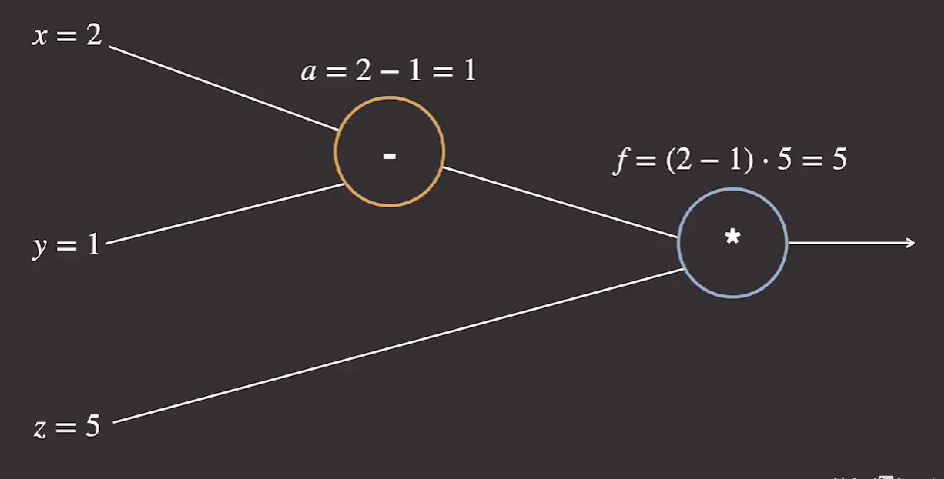

In [44]:
# compute a
a =  x-y
# define function f
f = z * a
print("final value of f: ", f)

f.backward()
#print gradient values
print("gradient of x", x.grad)
print("gradient of y", y.grad)
print("gradient of z", z.grad)

final value of f:  tensor([5.], grad_fn=<MulBackward0>)
gradient of x tensor([10.])
gradient of y tensor([-10.])
gradient of z tensor([2.])
